In [ ]:
'''
Shobhit-Sinha
Theoretical Questions:

1. What is unsupervised learning in the context of machine learning?

Unsupervised learning is a type of machine learning where the model is trained on data without labeled outputs. Unlike supervised learning, where each\
training example is paired with a correct output (like classifying images with known labels), in unsupervised learning, the algorithm tries to discover
patterns or structures in the input data on its own.

Main Goals of Unsupervised Learning:
1. Clustering: Grouping data points based on similarity.

 . Example: Customer segmentation (grouping customers by purchasing behavior).

 . Algorithms: K-Means, DBSCAN, Hierarchical Clustering.

2. Dimensionality Reduction: Reducing the number of features while retaining important information.

. Example: Visualizing high-dimensional data in 2D or 3D.

. Algorithms: PCA (Principal Component Analysis), t-SNE, UMAP.

3. Anomaly Detection: Identifying data points that don't fit the normal pattern.

. Example: Fraud detection in financial transactions.

4. Association Rule Learning: Finding relationships between variables in large datasets.

. Example: Market basket analysis (e.g., people who buy bread also buy butter).

. Algorithms: Apriori, Eclat.

 Real-World Analogy:
Imagine you're given a box of mixed Lego bricks without instructions. You don’t know what you're supposed to build (no labels), but by examining the 
pieces, you start to group them by color, shape, or size—that’s like clustering in unsupervised learning.

In [ ]:
'''
2. How does K-Means clustering algorithm work?

Great question! K-Means is one of the most popular and intuitive clustering algorithms in unsupervised learning. Here's a breakdown of how it works:

 Goal:
To partition a dataset into K distinct, non-overlapping groups (clusters), where each data point belongs to the cluster with the nearest mean (called 
the cluster centroid).

How K-Means Works (Step-by-Step):
1. Choose the number of clusters (K).

    . You decide how many groups you want to divide the data into.

2. Initialize centroids randomly.

    . Randomly select K data points as the initial centroids (the "center" of each cluster).

3. Assign points to the nearest centroid.

    . For each data point, compute the distance (usually Euclidean) to each centroid.

    . Assign the point to the cluster with the closest centroid.

4. Recalculate centroids.

    . For each cluster, calculate the new centroid by averaging all the points assigned to that cluster.

5. Repeat steps 3 and 4 until convergence:

    . That means the centroids no longer change significantly, or a maximum number of iterations is reached.

Example (Visually):
. Imagine you have a scatter plot of customer locations:

. You want to group them into 3 market zones.

. K-Means will find 3 "centers" and assign each customer to the closest one.
'''

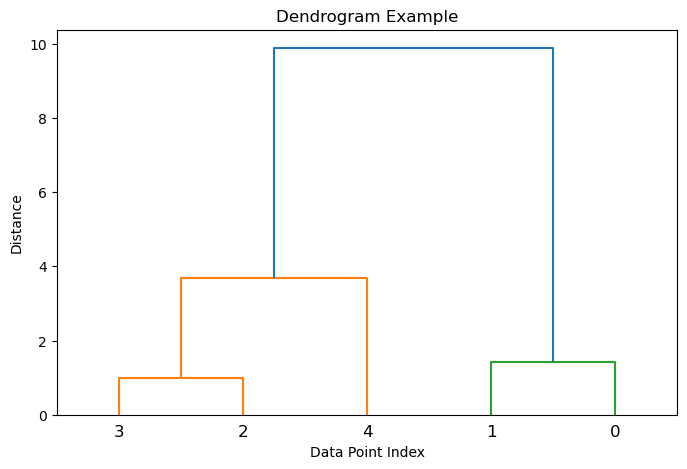

In [1]:
'''
3. Explain the concept of a dendrogram in hierarchical clustering.

A dendrogram is a key concept and visual tool used in hierarchical clustering to show how data points are grouped together at different levels of
similarity.

 What is a Dendrogram?
A dendrogram is a tree-like diagram that illustrates the arrangement of the clusters produced by hierarchical clustering. It shows how clusters are
merged or split step-by-step based on their distance (or dissimilarity).

 How It’s Used:
You can "cut" the dendrogram at a specific height to choose the number of clusters you want.

. Higher cut = fewer clusters (more general grouping)

. Lower cut = more clusters (more fine-grained grouping)

Types of Hierarchical Clustering:

1. Agglomerative (Bottom-Up) – Start with each point as its own cluster, then merge the closest pairs.

2. Divisive (Top-Down) – Start with all points in one cluster, then split into smaller clusters.

  Dendrograms are typically used with agglomerative clustering.

Example Use Case:
Imagine clustering animals based on features:

 . Cats and lions might cluster together early (short branch).

 . Birds and reptiles might connect much higher up (longer branch = less similar).
'''
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

# Sample data (simple 2D points)
data = np.array([
    [1, 2],
    [2, 1],
    [5, 5],
    [6, 5],
    [8, 7]
])

# Step 1: Compute the linkage matrix
linked = linkage(data, method='ward')  # 'ward' minimizes variance within clusters

# Step 2: Plot the dendrogram
plt.figure(figsize=(8, 5))
dendrogram(linked,
           orientation='top',
           distance_sort='descending',
           show_leaf_counts=True)
plt.title('Dendrogram Example')
plt.xlabel('Data Point Index')
plt.ylabel('Distance')
plt.show()


In [ ]:
'''
4. What is the main difference between K-Means and Hierarchical Clustering?
🔑 Main Differences Between K-Means and Hierarchical Clustering:

Feature	                                  K-Means	                                               Hierarchical Clustering
Approach	                        Partitioning method	                                       Hierarchical method (builds a tree)
Number of Clusters (K)	       Must be specified before running	                              Not needed initially; can be chosen after
Structure Output	             Flat clusters (no hierarchy)	                                 Dendrogram (tree structure)
Algorithm Type	                   Iterative optimization	                                   Recursive merging (agglomerative) or splitting
Scalability	                      Better for large datasets	                                     Slower, more memory-intensive
Cluster Shape Assumption	    Prefers spherical, equally-sized	                          Can handle non-spherical clusters better
Result Stability	           Sensitive to initialization (random)	                            More stable (deterministic unless ties)
Visualization Tool	               Often uses scatter plots	                                           Uses dendrograms
'''

In [ ]:
'''
5. What are the advantages of DBSCAN over K-Means?
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) has some powerful advantages over K-Means, especially for real-world, messy 
datasets.

Advantages of DBSCAN over K-Means:

Feature	                                              DBSCAN	                                   K-Means
No need to specify number of clusters	    Does not require K	                                   Must specify K upfront
Handles arbitrary-shaped clusters	      Can find non-spherical clusters	                       Prefers spherical, equally-sized clusters
Robust to noise and outliers	    Explicitly identifies and separates outliers	               Sensitive to outliers, which can distort centroids
Automatic cluster discovery	  Detects the optimal number of clusters based on density               Fixed number of clusters
Deterministic results	 Produces the same result each time (if eps and min_samples are fixed)	  Results can vary due to random centroid initialization

Where DBSCAN Might Struggle:
. High-dimensional data: It uses distance metrics, which become less meaningful in high dimensions.

. Varying density clusters: DBSCAN assumes that all clusters have roughly the same density. If your data has dense and sparse clusters, it might not
  work well.

. Parameter tuning: You need to set eps (radius) and min_samples, and picking good values isn’t always obvious.

TL;DR:
. DBSCAN is your go-to when:

    . You don’t know how many clusters exist.

    . You expect noise/outliers.

    . Clusters have weird shapes.

. K-Means is better when:

    . You know K.

    . Clusters are spherical and similar in size.

    . Performance on large, clean datasets matters.


'''

In [ ]:
'''
6. When would you use Silhouette Score in clustering?
The Silhouette Score is a super handy metric for evaluating the quality of clustering, especially when you're trying to figure out how well your 
algorithm has grouped the data.

 When to Use the Silhouette Score:
You’d typically use the Silhouette Score in these scenarios:

1. To Choose the Optimal Number of Clusters (K):
. In K-Means, you don’t always know what K should be.

. You can compute the Silhouette Score for different values of K and pick the one with the highest average score.

2. To Evaluate the Overall Quality of Clustering:
. It tells you how well each data point fits within its cluster versus other clusters.

. High score = well-separated and tight clusters.

. Low or negative score = overlapping or wrongly clustered points.

 3. To Compare Different Clustering Algorithms:
. Trying K-Means vs. DBSCAN vs. Hierarchical? You can use the Silhouette Score as a consistent measure to compare their performance.

 How It Works:
 For each point:

. a = average distance to all other points in the same cluster (intra-cluster distance)

. b = average distance to all points in the nearest different cluster (nearest-cluster distance)

Then the silhouette score for the point is:
s= max(a,b)
  ________
     b−a
. ​Range: -1 to +1
. +1 → well-clustered
. 0 → on the boundary
. -1 → likely in the wrong cluster
'''

In [ ]:
'''
7. What are the limitations of Hierarchical Clustering?

Hierarchical clustering is a useful unsupervised learning technique, especially for identifying nested groupings in data. However, it has several 
limitations:

1. Irreversibility (Greedy Algorithm Limitation)
Once a merge (or split) is made, it can’t be undone. This greedy nature can lead to suboptimal clusters because early mistakes propagate through the
process.

2. Sensitive to Distance Metric and Linkage Criteria
The outcome heavily depends on:

    . The distance metric (Euclidean, Manhattan, cosine, etc.)

    . The linkage method (single, complete, average, Ward’s, etc.)

Different combinations can yield very different clusters.

3. No Objective Function
Unlike k-means (which minimizes within-cluster variance), hierarchical clustering lacks a clear optimization goal, making it harder to evaluate the
"best" clustering.

4.No Natural Way to Choose Number of Clusters
The dendrogram gives a visual guide, but deciding where to "cut" it to choose k clusters can be subjective.

5. Sensitive to Noise and Outliers
Outliers can skew the distance calculations and distort the hierarchy, especially in single-linkage clustering (which can lead to chaining effects).

6. Hard to Update
If new data points are added, you often need to recompute the entire hierarchy, unlike k-means which can be updated incrementally.


'''

In [ ]:
'''
8. Why is feature scaling important in clustering algorithms like K-Means?

1. K-Means is Distance-Based
K-Means relies on Euclidean distance to compute:

. Distances between data points

. Distances from points to centroids

If features are on different scales, those with larger ranges will dominate the distance calculation, skewing the clustering results.

Example:
Imagine two features:

    . Age: ranges from 0 to 100

    . Income: ranges from 0 to 100,000

Without scaling, the income feature would overpower the age feature completely in the distance calculation—so clustering would mostly be based on 
income, not a balance of both.

2. Feature Importance Becomes Biased
When features aren't scaled, K-Means implicitly assumes that high-range features are more important, which isn't always the case. This can lead to poor
cluster formation.

 3. Centroid Calculation Gets Skewed
K-Means uses mean values to find centroids. If some features have much higher values than others, the centroids get pulled toward those features, 
distorting the cluster centers.

'''

In [ ]:
'''
9. How does DBSCAN identify noise points?

DBSCAN is really good at handling noise, which sets it apart from methods like K-Means. Here's how it identifies noise points:

How DBSCAN Works
DBSCAN (Density-Based Spatial Clustering of Applications with Noise) groups data points based on density. It needs two key parameters:

. eps (epsilon): radius to search for neighbors

. minPts: minimum number of points to form a dense region

Based on these, it classifies each point as one of three types:

 1. Core Point
. Has at least minPts within its eps neighborhood

. Forms the core of a cluster

 2. Border Point
. Has fewer than minPts in its eps neighborhood, but…

. Is within the eps distance of a core point

. Considered part of a cluster, but not a core

3. Noise Point (Outlier)
A point is labeled as noise if:

. It is not a core point

. AND is not reachable from any core point

These points don't belong to any cluster.

 So, TL;DR:
Noise points in DBSCAN are those that lie in low-density areas and aren't close enough to any dense group of points to be part of a cluster.

Example:
. Imagine you're clustering stars in space:

. A tightly packed galaxy = a cluster (core points)

. Stars on the outskirts = border points

. A lone star far away = noise
'''

In [ ]:
'''
10. Define inertia in the context of K-Means.

In the context of K-Means clustering, inertia is a measure of how well the data points are clustered around the centroids. More specifically, it is the
sum of squared distances between each data point and the centroid of the cluster to which it belongs.

Interpretation:
. Lower inertia means that data points are closer to their assigned centroids, indicating tighter, more compact clusters.

. Higher inertia indicates more spread-out clusters.
'''


In [ ]:
'''
11. What is the elbow method in K-Means clustering?

Concept:
As you increase the number of clusters k, the inertia (i.e. the sum of squared distances from each point to its assigned cluster center) naturally
decreases — because having more clusters means each point is likely closer to a centroid.

But after a certain point, the rate of improvement drops sharply — this point is called the "elbow", and it's often the ideal number of clusters.

How it works:
1. Run K-Means clustering for a range of values of k (e.g., 1 to 10).

2.Compute the inertia for each k.

3.Plot k (number of clusters) on the x-axis and inertia on the y-axis.

4. Look for the point where the curve bends — like an elbow. This is your optimal k.

Why it’s called the “elbow” method:
Because the graph of inertia vs. number of clusters often looks like a bent arm — and the best trade-off point (where adding more clusters stops giving
big gains) looks like an elbow joint.

Why it’s called the “elbow” method:
Because the graph of inertia vs. number of clusters often looks like a bent arm — and the best trade-off point (where adding more clusters stops giving
big gains) looks like an elbow joint.
'''

In [ ]:
'''
12. Describe the concept of "density" in DBSCAN.

In DBSCAN (Density-Based Spatial Clustering of Applications with Noise), the concept of density is central to how clusters are formed.

What is “density” in DBSCAN?
In DBSCAN, density refers to how closely packed the data points are in a region. A cluster is a region where the density of points exceeds a certain 
threshold.

Key Concepts in DBSCAN:
1. ε (epsilon):
 A distance threshold — defines the neighborhood around a point.

2. MinPts (minimum points):
 The minimum number of data points that must be within the ε-radius of a point for it to be considered a core point.

 Types of Points Based on Density:
. Core Point:
A point that has at least MinPts within its ε-neighborhood (including itself).
→ Indicates high-density region.

. Border Point:
Has fewer than MinPts in its ε-neighborhood, but lies within the neighborhood of a core point.
→ On the edge of a dense region.

. Noise Point (Outlier):
Not a core point and not within the ε-neighborhood of any core point.
→ Lies in a low-density region.

Density in DBSCAN is defined by:

How many points are within a specified distance (ε),

Compared to a minimum count (MinPts).

Clusters are formed by connecting dense regions of core points and their neighbors — making DBSCAN great at finding arbitrarily shaped clusters and 
filtering out noise.



'''

In [ ]:
'''
13. Can hierarchical clustering be used on categorical data?

Yes, hierarchical clustering can be used on categorical data, but with some important considerations. Since hierarchical clustering is based on distance
or similarity between data points, the key challenge is choosing an appropriate distance metric for categorical variables.

How to use hierarchical clustering on categorical data:
1. Use a distance metric suited for categorical data, such as:

    . Hamming distance: Counts how many attributes differ between two data points.

    . Simple matching coefficient: Measures similarity based on how many values match.

    . Jaccard distance: Useful when data is binary or sparse (e.g., presence/absence).

2. Convert categories if needed:

    . If your data is nominal (non-ordered categories), you can one-hot encode it.

    . If it’s ordinal (ordered categories), you can map values to integers.

3. Choose a linkage method:

    . Common ones like single, complete, average, or ward (note: Ward only works with numerical data and Euclidean distances).

4. Use tools/libraries that support it:

    . Python’s scipy.cluster.hierarchy or sklearn (with precomputed distance matrices).

    . The gower distance is another good choice when you have mixed data types (categorical + numerical).

Example use case:
Clustering customers based on:

. Gender (categorical)

. Marital Status (categorical)

. Product preferences (categorical)

You could compute a distance matrix using Hamming or Jaccard distance and then apply agglomerative hierarchical clustering on it.
'''

In [ ]:
'''
14. What does a negative Silhouette Score indicate?

A negative Silhouette Score indicates that a data point is, on average, closer to points in another cluster than to points in its own cluster — which 
usually means poor clustering.

Interpretation of the score:
Score Range	                                   Interpretation
+1	                                   Point is well-matched to its own cluster and far from other clusters
0	                                   Point is on or very close to the decision boundary between two clusters
Negative	                           Point is likely assigned to the wrong cluster — it's closer to a different one

a negative Silhouette Score suggests:
. The point might have been misclassified.

. There’s probably overlapping clusters or poor separation.

. The current clustering structure doesn’t represent the data well.
'''

In [ ]:
'''
15. Explain the term "linkage criteria" in hierarchical clustering.

In hierarchical clustering, "linkage criteria" refers to the method used to determine the distance between two clusters, which dictates how clusters are
merged during the process. Different linkage criteria, such as single, complete, average, or Ward's linkage, each have distinct ways of measuring
distance and, consequently, influence the shape and structure of the resulting clusters. 

Elaboration:
Hierarchical clustering algorithms build a hierarchy of clusters, starting with individual data points as separate clusters and iteratively merging the
most similar clusters until a single, encompassing cluster is formed. The choice of linkage criterion is crucial as it defines how the "distance"
between two clusters is calculated, impacting the merging decisions at each step. 

Common Linkage Criteria:
Single Linkage:
Determines the distance between two clusters based on the minimum distance between any two points, one from each cluster. This tends to create
elongated, string-like clusters. 

Complete Linkage:
Defines the distance as the maximum distance between any two points, one from each cluster. This approach tends to form more compact, well-defined
clusters. 

Average Linkage:
Calculates the average distance between all pairs of points, one from each cluster. This method often provides a balance between the extremes of single
and complete linkage. 

Ward's Linkage:
Minimizes the increase in within-cluster variance when merging two clusters. This method tends to create clusters of similar sizes and shapes. 

Centroid Linkage:
Measures the distance between the centroids (average points) of the two clusters. 
'''

In [ ]:
'''
16. Why might K-Means clustering perform poorly on data with varying cluster sizes or densities?

1. Assumes Equal Cluster Sizes
K-Means tries to minimize the distance of points to their cluster centroids — which works best when clusters are roughly the same size and shape.
- If you have small and large clusters, K-Means may incorrectly assign points from a small cluster to a nearby larger one.

2. Assumes Similar Densities
K-Means also assumes clusters have similar densities.
- If one cluster is tightly packed and another is spread out, K-Means might split the dense one or merge part of it with the sparse one.

3. Spherical Clusters Bias
K-Means implicitly assumes clusters are spherical and convex (because it uses Euclidean distance and assigns points based on proximity to centroids).
- It struggles with elongated, non-spherical, or complex-shaped clusters.

4. Sensitive to Outliers
Outliers can pull centroids in the wrong direction, especially when clusters have different densities, leading to poor boundary decisions.

Example Failure Case:
Imagine one tight cluster and one spread-out cluster. K-Means may:

. Split the large one into multiple clusters

. Assign points from the small cluster to the big one

. Place centroids awkwardly between real cluster centers
'''

In [ ]:
'''
17. What are the core parameters in DBSCAN, and how do they influence clustering?
In DBSCAN (Density-Based Spatial Clustering of Applications with Noise), the two core parameters that directly influence how clusters are formed are:

 1. eps (epsilon)
. Definition: The maximum distance between two points for them to be considered neighbors.

. Influence:

. Controls the neighborhood radius around each point.

. A smaller eps results in more clusters and potentially more noise/outliers.

. A larger eps can lead to fewer, larger clusters or even merging distinct clusters together.

2. min_samples (or MinPts)
. Definition: The minimum number of points required within the eps neighborhood for a point to be considered a core point.

. Influence:

. Determines how dense a region must be to form a cluster.

. Higher min_samples → requires denser areas to form clusters → more points labeled as noise.

. Lower min_samples → allows sparser regions to form clusters → may result in more small clusters or noise being included.

How they work together:
. A point is a core point if there are at least min_samples points within its eps neighborhood.

. Clusters form when core points are connected via their neighborhoods.

. Points that are not core points but fall within the eps of a core point are border points.

. Points that are neither core nor border are noise/outliers.

Choosing the right values:

. Use a k-distance graph (plot distance to the k-th nearest neighbor for each point) to help select a good eps.

. A typical rule of thumb: set min_samples to 2 × number of dimensions, but tweak based on data.

Summary:
Parameter	  Controls	                             Too Small	                             Too Large
eps	         Neighborhood size	                Too many clusters, noise	              Clusters merge, less detail
min_samples	 Density required to form core	   Loose clusters, less noise	              Fewer clusters, more noise

'''

In [ ]:
'''
18. How does K-Means++ improve upon standard K-Means initialization?
 K-Means++ is an improved version of the standard K-Means algorithm — specifically designed to make the initialization of centroids smarter, which often
 leads to better clustering results and faster convergence.

 Problem with standard K-Means initialization:
In vanilla K-Means:

. Initial centroids are chosen randomly.

. This randomness can lead to:

    . Poor clustering results (local minima),

    . Slow convergence,

    . Empty or overlapping clusters.

How K-Means++ improves it:
K-Means++ chooses initial centroids more strategically to spread them out across the data.

Steps:
1. Randomly choose the first centroid from the data points.
2. For each remaining data point:

    . Compute the distance squared to the nearest existing centroid.

3. Select the next centroid from the data points with probability proportional to that squared distance.

    . So, points farther away from current centroids are more likely to be chosen.

4. Repeat until k centroids are initialized.

5. Proceed with standard K-Means.

 Why this helps:

. Reduces chances of poor initialization

. Leads to better clustering results

. Faster convergence (fewer iterations needed)

. More stable — less sensitive to random seeds

Summary:
Feature	                    K-Means	                            K-Means++
Initialization	       Completely random	            Spread out, distance-aware
Convergence Speed	       Slower	                         Typically faster
Result Quality	     May vary (local minima)	        Often better, more consistent

'''

In [ ]:
'''
19. What is agglomerative clustering?

Agglomerative clustering is a type of hierarchical clustering that builds clusters bottom-up — by successively merging the closest pairs of clusters
until all points are grouped into one big cluster (or until a stopping condition is met, like a desired number of clusters).

Key Idea:
Start with each data point as its own cluster, then merge the two closest clusters at each step based on a chosen distance (linkage) criterion.

 How it works (step-by-step):
1. Start: Each data point is a cluster (so you have n clusters for n points).

2. Compute distances between all pairs of clusters.

3. Merge the closest two clusters.

4. Update the distance matrix to reflect the new cluster.

5. Repeat steps 2–4 until:

. Only one cluster remains (full dendrogram), or

. A pre-defined number of clusters is reached.

 Linkage criteria (how “closest” is defined):

. Single Linkage: Minimum distance between any two points in the clusters.

. Complete Linkage: Maximum distance between any two points.

. Average Linkage: Average pairwise distance between all points in both clusters.

. Ward’s Method: Minimizes the increase in variance (works best with Euclidean distance).

 Dendrogram:

. The merging process can be visualized as a dendrogram, a tree-like diagram that shows the order and distance of cluster merges.

. You can cut the dendrogram at a certain level to get the desired number of clusters.

 Advantages:
. Doesn’t require you to pre-specify the number of clusters (you can choose it later by cutting the dendrogram).

. Works well with different distance metrics and linkage methods.

. Can find nested clusters or non-convex shapes (depending on linkage method).



In [ ]:
'''
20. What makes Silhouette Score a better metric than just inertia for model evaluation?

The Silhouette Score is a better metric than inertia for model evaluation because it considers both cluster cohesion (how tightly points are within a
cluster) and separation (how well-separated clusters are from each other). Inertia, on the other hand, only focuses on cluster compactness, potentially 
missing important aspects of cluster structure. 

Inertia (Within-Cluster Sum of Squares):
Measures how spread out data points are within a cluster. Lower inertia suggests tighter, more cohesive clusters. However, inertia doesn't account for
separation between clusters. A model could have high inertia (poorly separated clusters) but still have relatively tight clusters within themselves, 
which might not be ideal.

Silhouette Score:
Calculates how well each data point is assigned to its cluster by considering its distance to other points in the same cluster (cohesion) and its
distance to points in other clusters (separation). The score ranges from -1 to 1, where higher values indicate better-defined clusters with strong 
cohesion and separation.

In essence:
Inertia is useful for understanding cluster tightness but doesn't provide information about cluster separation.
Silhouette Score provides a more comprehensive view by considering both cohesion and separation, offering a more nuanced assessment of cluster quality. 

When the Silhouette Score is more valuable:
. When you want to understand how well-separated clusters are from each other. 
. When you need to determine the optimal number of clusters (k) for K-means. 
. When you're dealing with datasets where clusters might be irregularly shaped or of varying sizes, as the Silhouette Score is more robust to these
  variations. 
'''

D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


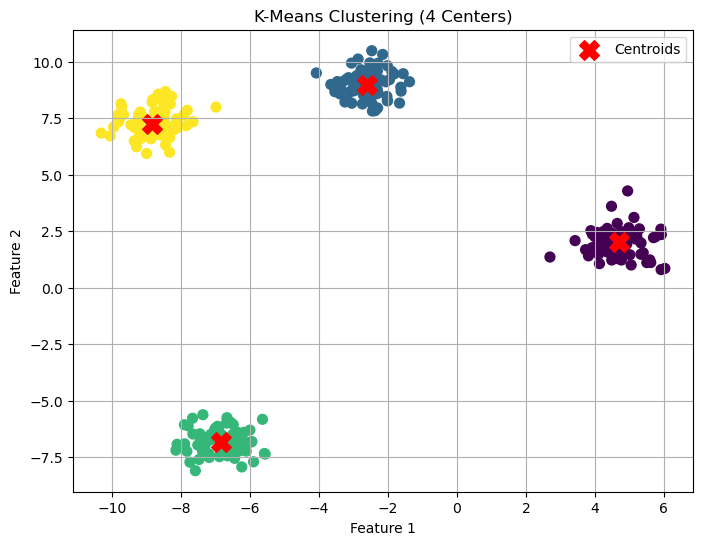

In [8]:
'''
Practical Questions:
21. Generate synthetic data with 4 centers using make_blobs and apply K-Means clustering. Visualize using a
scatter plot.
'''
import os
os.environ["OMP_NUM_THREADS"] = "2"  # Prevent MKL warning on Windows

import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=42)

# Apply K-Means
kmeans = KMeans(n_clusters=4, n_init=10, random_state=42)
y_kmeans = kmeans.fit_predict(X)

# Visualize
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis')

# Centroids
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Centroids')

plt.title("K-Means Clustering (4 Centers)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()



In [9]:
'''
22. Load the Iris dataset and use Agglomerative Clustering to group the data into 3 clusters. Display the first 10
predicted labels.
'''
from sklearn.datasets import load_iris
from sklearn.cluster import AgglomerativeClustering

# 1. Load the Iris dataset
iris = load_iris()
X = iris.data  # we use all 4 features

# 2. Apply Agglomerative Clustering
agg = AgglomerativeClustering(n_clusters=3)
labels = agg.fit_predict(X)

# 3. Display the first 10 predicted labels
print("First 10 predicted labels:", labels[:10])


First 10 predicted labels: [1 1 1 1 1 1 1 1 1 1]


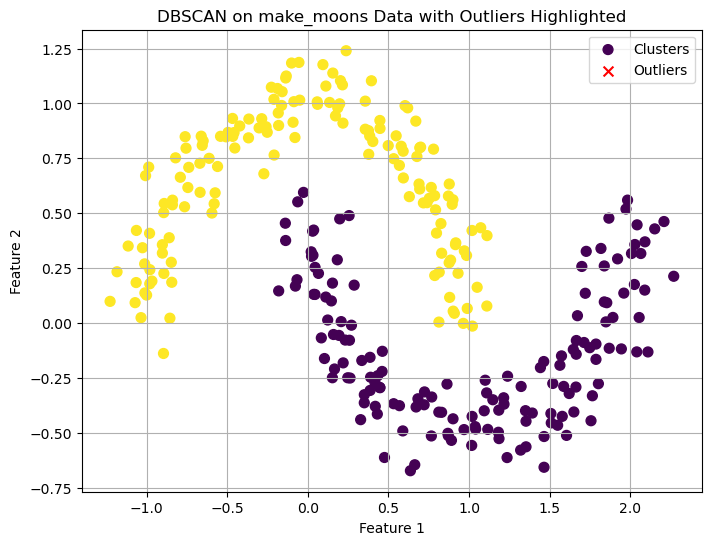

In [10]:
'''
23. Generate synthetic data using make_moons and apply DBSCAN. Highlight outliers in the plot.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Generate synthetic "moons" data
X, y = make_moons(n_samples=300, noise=0.1, random_state=42)

# 2. Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Identify outliers (label == -1)
outliers = labels == -1
core_points = labels != -1

# 4. Plot
plt.figure(figsize=(8, 6))
# Plot core cluster points
plt.scatter(X[core_points, 0], X[core_points, 1], c=labels[core_points], cmap='viridis', s=50, label='Clusters')
# Plot outliers in red
plt.scatter(X[outliers, 0], X[outliers, 1], c='red', s=50, label='Outliers', marker='x')

plt.title("DBSCAN on make_moons Data with Outliers Highlighted")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


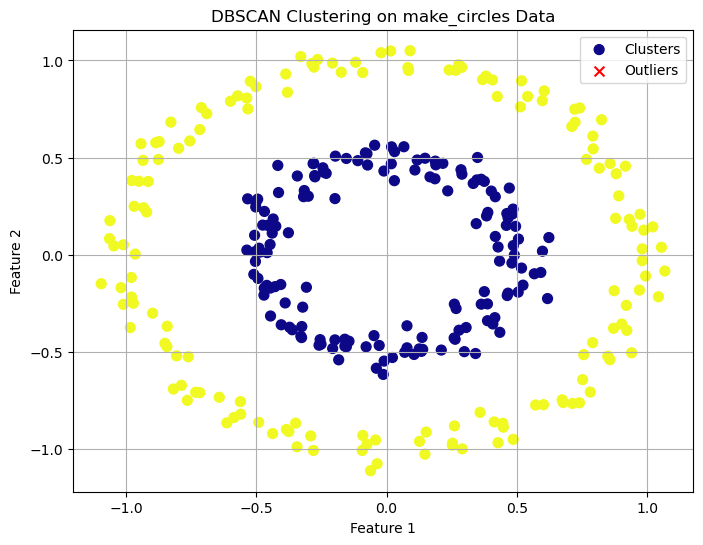

In [11]:
'''
25. Use make_circles to generate synthetic data and cluster it using DBSCAN. Plot the result.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Generate synthetic circular data
X, y = make_circles(n_samples=300, factor=0.5, noise=0.05, random_state=42)

# 2. Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Identify outliers
outliers = labels == -1
core_points = labels != -1

# 4. Plot the results
plt.figure(figsize=(8, 6))
# Plot clustered points
plt.scatter(X[core_points, 0], X[core_points, 1], c=labels[core_points], cmap='plasma', s=50, label='Clusters')
# Highlight outliers
plt.scatter(X[outliers, 0], X[outliers, 1], c='red', s=50, marker='x', label='Outliers')

plt.title("DBSCAN Clustering on make_circles Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


In [16]:
'''
26. Load the Breast Cancer dataset, apply MinMaxScaler, and use K-Means with 2 clusters. Output the cluster
centroids.
'''
import os
os.environ["OMP_NUM_THREADS"] = "3"
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import MinMaxScaler
from sklearn.cluster import KMeans
import pandas as pd

# 1. Load the dataset
data = load_breast_cancer()
X = data.data  # Feature matrix

# 2. Scale features using MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)

# 3. Apply K-Means with 2 clusters
kmeans = KMeans(n_clusters=2, n_init=10, random_state=42)
kmeans.fit(X_scaled)

# 4. Output the cluster centroids
centroids = kmeans.cluster_centers_

# Optional: Display centroids as a DataFrame for readability
centroid_df = pd.DataFrame(centroids, columns=data.feature_names)
print("Cluster Centroids (scaled features):\n")
print(centroid_df)


D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=3.
  warnings.warn(


Cluster Centroids (scaled features):

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0     0.255354      0.288335        0.246964   0.143884         0.357431   
1     0.504836      0.395603        0.505787   0.363766         0.469887   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0          0.180195        0.103448              0.13066       0.340118   
1          0.422263        0.418387              0.46928       0.458997   

   mean fractal dimension  ...  worst radius  worst texture  worst perimeter  \
0                0.255916  ...      0.205241       0.320690         0.192421   
1                0.299459  ...      0.480474       0.451074         0.465530   

   worst area  worst smoothness  worst compactness  worst concavity  \
0    0.099434          0.357112           0.148739         0.131423   
1    0.314606          0.498688           0.363915         0.390273   

   worst concave points  worst symmetry  worst fract

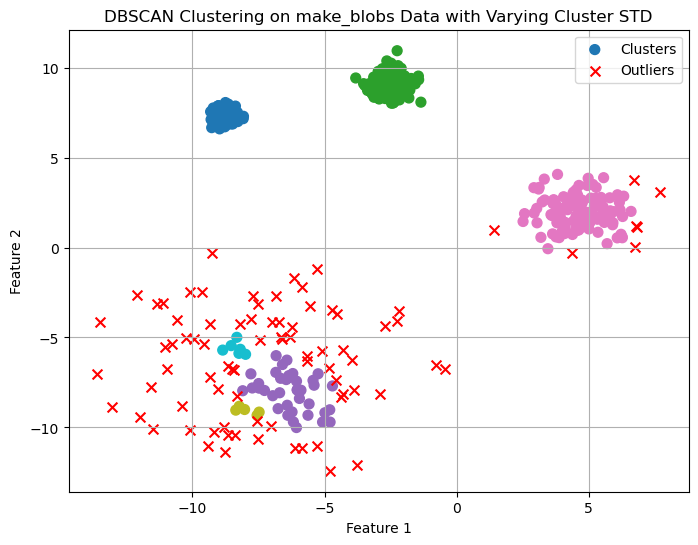

In [17]:
'''
27. Generate synthetic data using make_blobs with varying cluster standard deviations and cluster with
DBSCAN.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np

# 1. Generate synthetic data with varying std deviations
X, y = make_blobs(n_samples=500,
                  centers=4,
                  cluster_std=[0.5, 1.0, 2.5, 0.3],  # Different spreads
                  random_state=42)

# 2. Apply DBSCAN
dbscan = DBSCAN(eps=0.7, min_samples=5)
labels = dbscan.fit_predict(X)

# 3. Identify outliers
outliers = labels == -1
core_points = labels != -1

# 4. Plot the result
plt.figure(figsize=(8, 6))
# Clustered points
plt.scatter(X[core_points, 0], X[core_points, 1],
            c=labels[core_points], cmap='tab10', s=50, label='Clusters')

# Outliers
plt.scatter(X[outliers, 0], X[outliers, 1],
            c='red', marker='x', s=50, label='Outliers')

plt.title("DBSCAN Clustering on make_blobs Data with Varying Cluster STD")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.grid(True)
plt.show()


D:\ProgramData\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1382: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=8.
  warnings.warn(


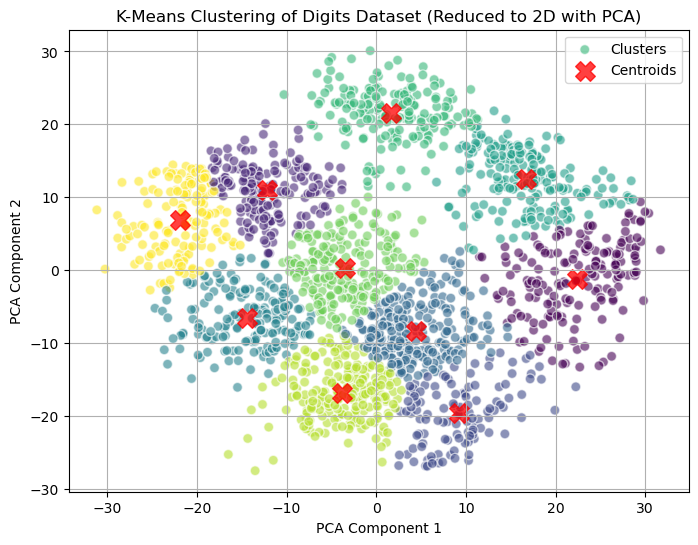

In [19]:
'''
28. Load the Digits dataset, reduce it to 2D using PCA, and visualize clusters from K-Means.
'''
import os
os.environ["OMP_NUM_THREADS"] = "8"  # Set to a reasonable number like 3 or 8 to avoid the memory leak

import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import numpy as np

# 1. Load the Digits dataset
digits = load_digits()
X = digits.data  # Feature matrix
y = digits.target  # True labels (optional for comparison)

# 2. Reduce to 2D using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# 3. Apply K-Means clustering with 10 clusters (digits are 10 classes)
kmeans = KMeans(n_clusters=10, n_init=10, random_state=42)  # Set n_init explicitly to avoid the warning
y_kmeans = kmeans.fit_predict(X_pca)

# 4. Visualize the clusters in 2D PCA space
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_kmeans, cmap='viridis', s=50, alpha=0.6, edgecolors='w', label='Clusters')

# Plot the centroids of the clusters
centroids = kmeans.cluster_centers_
plt.scatter(centroids[:, 0], centroids[:, 1], c='red', s=200, alpha=0.75, marker='X', label='Centroids')

plt.title("K-Means Clustering of Digits Dataset (Reduced to 2D with PCA)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.grid(True)
plt.show()


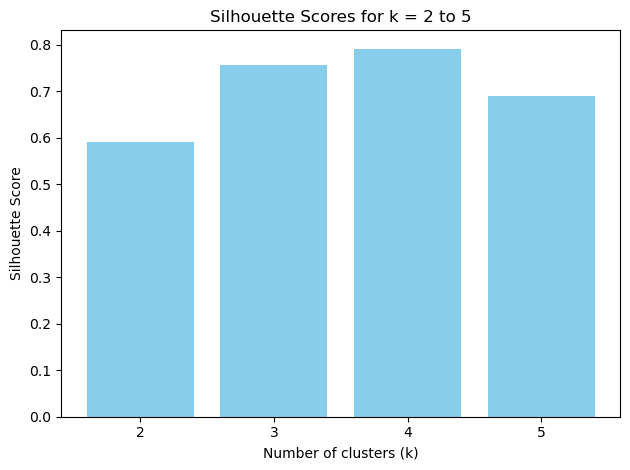

In [23]:
'''
29. Create synthetic data using make_blobs and evaluate silhouette scores for k = 2 to 5. Display as a bar chart.
'''
import os
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import warnings

# Suppress specific warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

# Set environment variable to avoid MKL memory leak on Windows
os.environ["OMP_NUM_THREADS"] = "2"

# Generate synthetic data
X, _ = make_blobs(n_samples=300, centers=4, random_state=42)

# Evaluate silhouette scores for k = 2 to 5
silhouette_scores = []

for k in range(2, 6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)  # Explicitly set n_init
    kmeans.fit(X)
    score = silhouette_score(X, kmeans.labels_)
    silhouette_scores.append(score)

# Plot silhouette scores
plt.bar(range(2, 6), silhouette_scores, color='skyblue')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Scores for k = 2 to 5')
plt.xticks(range(2, 6))
plt.tight_layout()
plt.show()


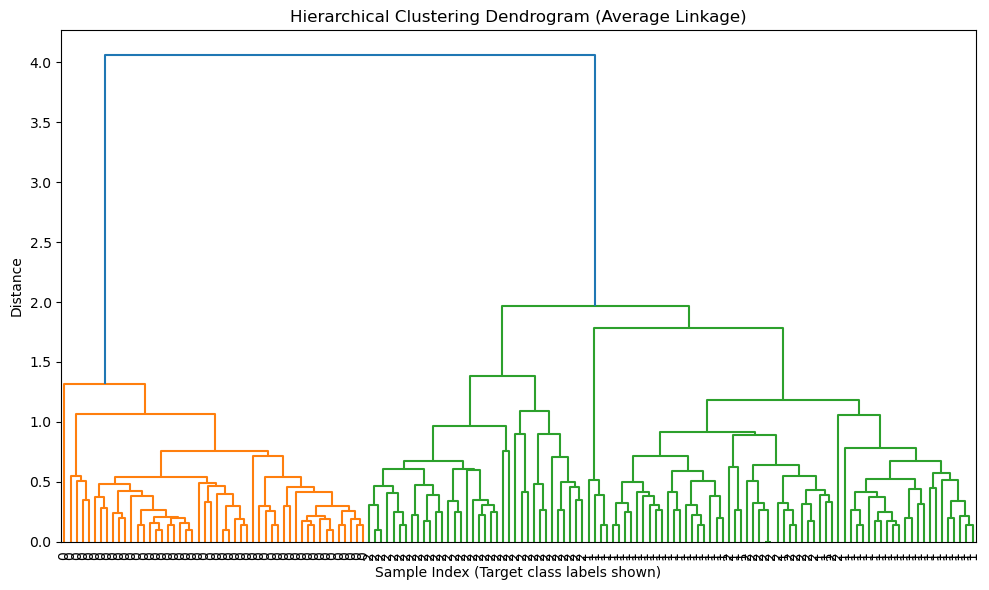

In [24]:
'''
30. Load the Iris dataset and use hierarchical clustering to group data. Plot a dendrogram with average linkage.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy.cluster.hierarchy import dendrogram, linkage

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Perform hierarchical clustering using average linkage
linked = linkage(X, method='average')

# Plot the dendrogram
plt.figure(figsize=(10, 6))
dendrogram(linked,
           labels=iris.target,
           leaf_rotation=90,
           leaf_font_size=10,
           color_threshold=0.7 * max(linked[:, 2]))  # Threshold for coloring branches

plt.title('Hierarchical Clustering Dendrogram (Average Linkage)')
plt.xlabel('Sample Index (Target class labels shown)')
plt.ylabel('Distance')
plt.tight_layout()
plt.show()


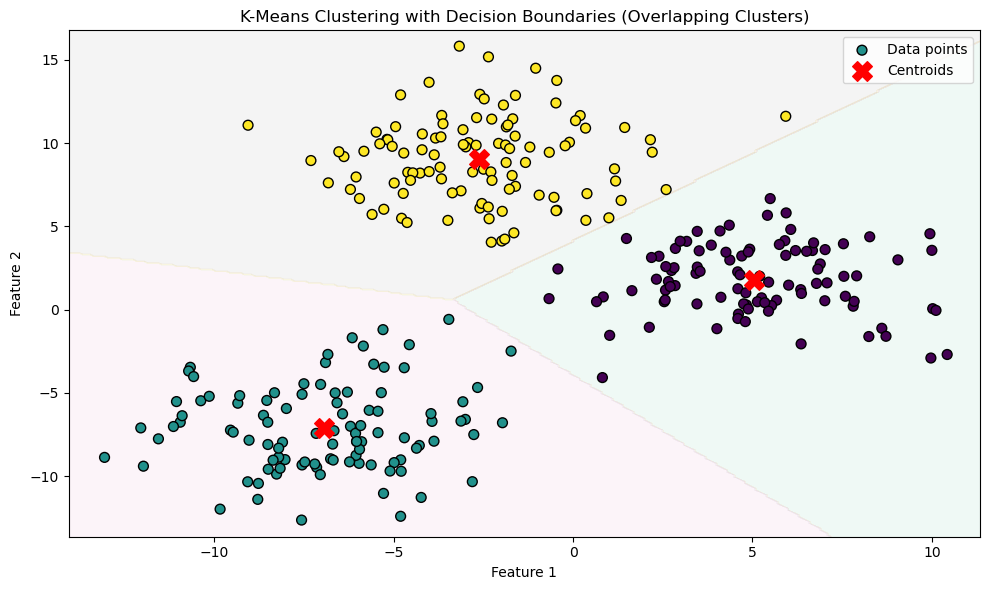

In [25]:
'''
31. Generate synthetic data with overlapping clusters using make_blobs, then apply K-Means and visualize with
decision boundaries.
'''
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data with overlapping clusters
X, y_true = make_blobs(n_samples=300,
                       centers=3,
                       cluster_std=2.5,  # Higher std = more overlap
                       random_state=42)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Create a meshgrid for decision boundaries
h = 0.1  # Step size in the mesh
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.figure(figsize=(10, 6))
plt.contourf(xx, yy, Z, alpha=0.2, cmap='Pastel2')

# Plot data points
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50, cmap='viridis', edgecolor='k', label='Data points')

# Plot cluster centers
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1],
            s=200, c='red', marker='X', label='Centroids')

plt.title("K-Means Clustering with Decision Boundaries (Overlapping Clusters)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()


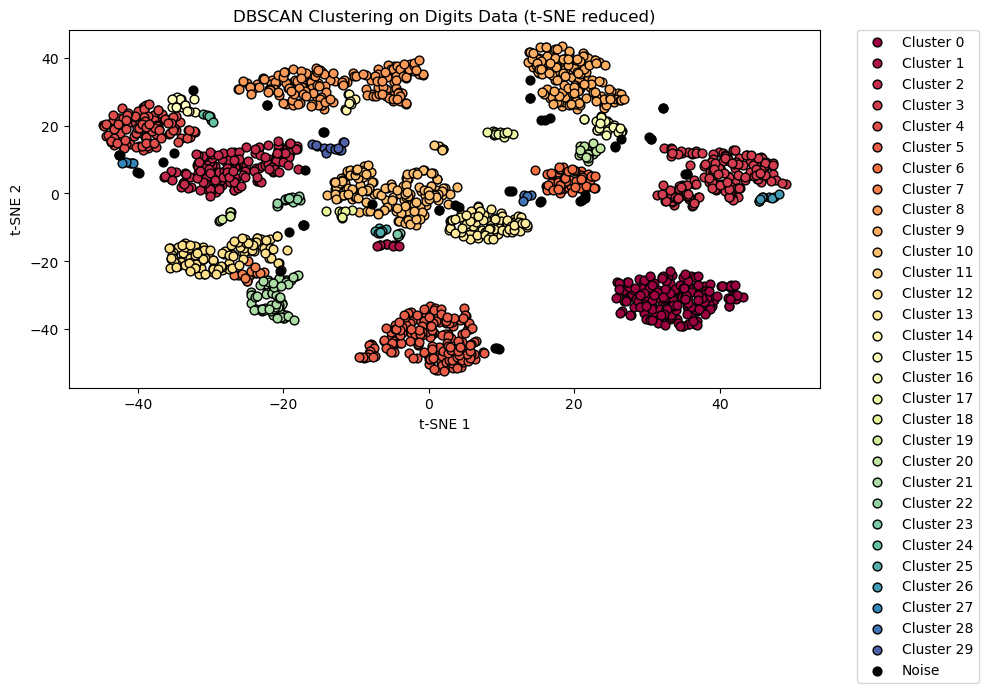

In [26]:
'''
32. Load the Digits dataset and apply DBSCAN after reducing dimensions with t-SNE. Visualize the results.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

# Load the digits dataset
digits = load_digits()
X = digits.data

# Standardize the data
X_scaled = StandardScaler().fit_transform(X)

# Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_scaled)

# Apply DBSCAN clustering
dbscan = DBSCAN(eps=2.0, min_samples=5)
labels = dbscan.fit_predict(X_tsne)

# Plot the results
plt.figure(figsize=(10, 6))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for label, color in zip(unique_labels, colors):
    if label == -1:
        # Noise (outliers)
        color = [0, 0, 0, 1]  # Black
        label_name = "Noise"
    else:
        label_name = f"Cluster {label}"
    
    class_member_mask = (labels == label)
    plt.scatter(X_tsne[class_member_mask, 0], 
                X_tsne[class_member_mask, 1],
                label=label_name, 
                c=[color], 
                edgecolors='k', 
                s=40)

plt.title("DBSCAN Clustering on Digits Data (t-SNE reduced)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.legend(loc='best', bbox_to_anchor=(1.05, 1), borderaxespad=0.)
plt.tight_layout()
plt.show()


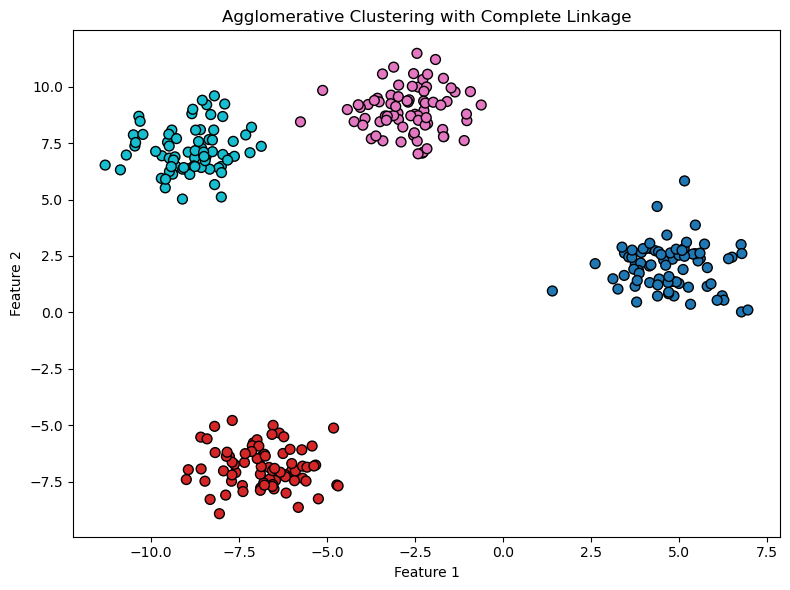

In [27]:
'''
33. Generate synthetic data using make_blobs and apply Agglomerative Clustering with complete linkage. Plot
the result.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=1.0, random_state=42)

# Apply Agglomerative Clustering with complete linkage
agglo = AgglomerativeClustering(n_clusters=4, linkage='complete')
labels = agglo.fit_predict(X)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=50)
plt.title("Agglomerative Clustering with Complete Linkage")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()


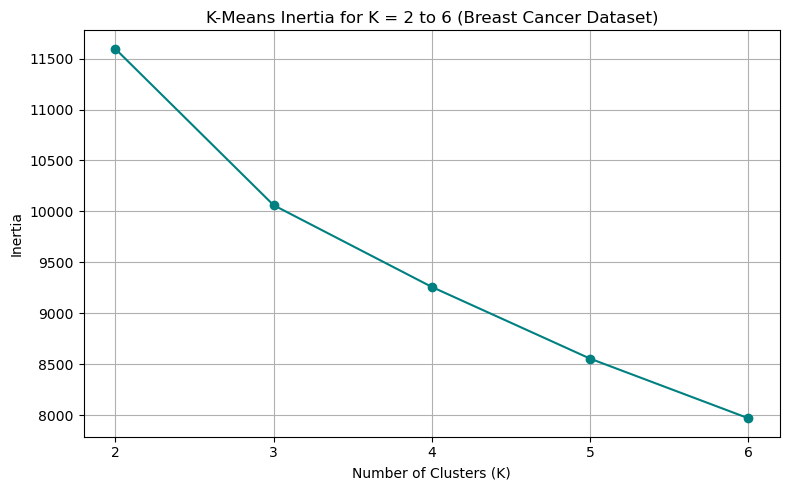

In [28]:
'''
34. Load the Breast Cancer dataset and compare inertia values for K = 2 to 6 using K-Means. Show results in a
line plot.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data

# Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Compute inertia for K = 2 to 6
inertias = []
K_values = range(2, 7)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

# Plot the inertia values
plt.figure(figsize=(8, 5))
plt.plot(K_values, inertias, marker='o', linestyle='-', color='teal')
plt.title('K-Means Inertia for K = 2 to 6 (Breast Cancer Dataset)')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_values)
plt.grid(True)
plt.tight_layout()
plt.show()


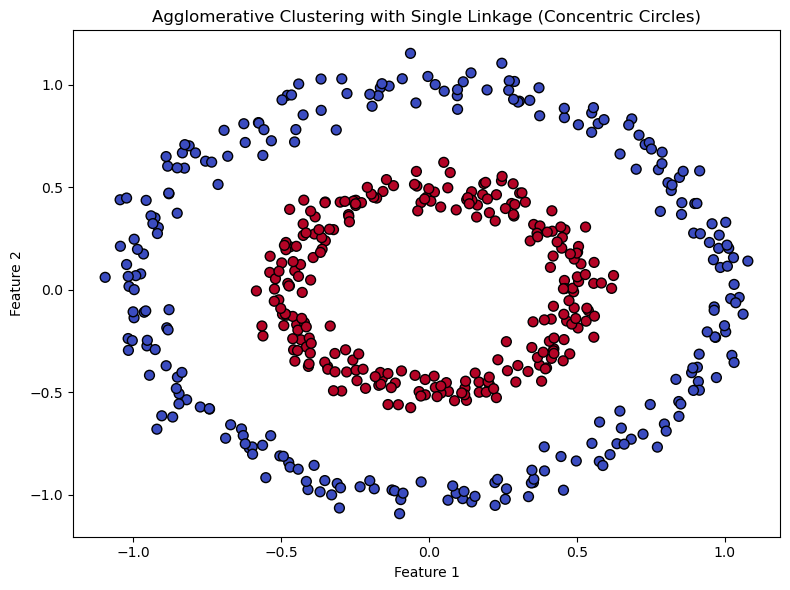

In [29]:
'''
35. Generate synthetic concentric circles using make_circles and cluster using Agglomerative Clustering with
single linkage.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import AgglomerativeClustering

# Generate synthetic concentric circles
X, y_true = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=42)

# Apply Agglomerative Clustering with single linkage
agglo = AgglomerativeClustering(n_clusters=2, linkage='single')
labels = agglo.fit_predict(X)

# Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='coolwarm', edgecolor='k', s=50)
plt.title("Agglomerative Clustering with Single Linkage (Concentric Circles)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.tight_layout()
plt.show()


In [30]:
'''
36. Use the Wine dataset, apply DBSCAN after scaling the data, and count the number of clusters (excluding
noise)
'''
from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Load the Wine dataset
data = load_wine()
X = data.data

# Scale the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=1.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

# Count number of clusters (excluding noise)
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters (excluding noise): {n_clusters}")
print(f"Number of noise points: {n_noise}")


Estimated number of clusters (excluding noise): 0
Number of noise points: 178


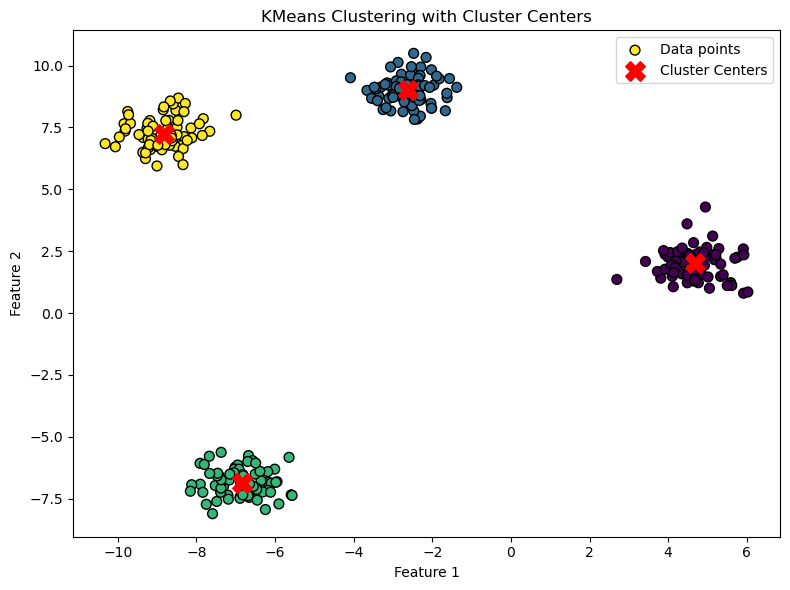

In [31]:
'''
37. Generate synthetic data with make_blobs and apply KMeans. Then plot the cluster centers on top of the
data points.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.6, random_state=42)

# Apply KMeans clustering
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
kmeans.fit(X)
labels = kmeans.labels_
centers = kmeans.cluster_centers_

# Plot data points
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k', label='Data points')

# Plot cluster centers
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, marker='X', label='Cluster Centers')

plt.title("KMeans Clustering with Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()


In [32]:
'''
38. Load the Iris dataset, cluster with DBSCAN, and print how many samples were identified as noise.
'''
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
import numpy as np

# Load the Iris dataset
iris = load_iris()
X = iris.data

# Standardize the data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Apply DBSCAN
dbscan = DBSCAN(eps=0.8, min_samples=5)  # You can tweak eps as needed
labels = dbscan.fit_predict(X_scaled)

# Count noise samples (label == -1)
n_noise = np.sum(labels == -1)

print(f"Number of noise samples identified by DBSCAN: {n_noise}")


Number of noise samples identified by DBSCAN: 4


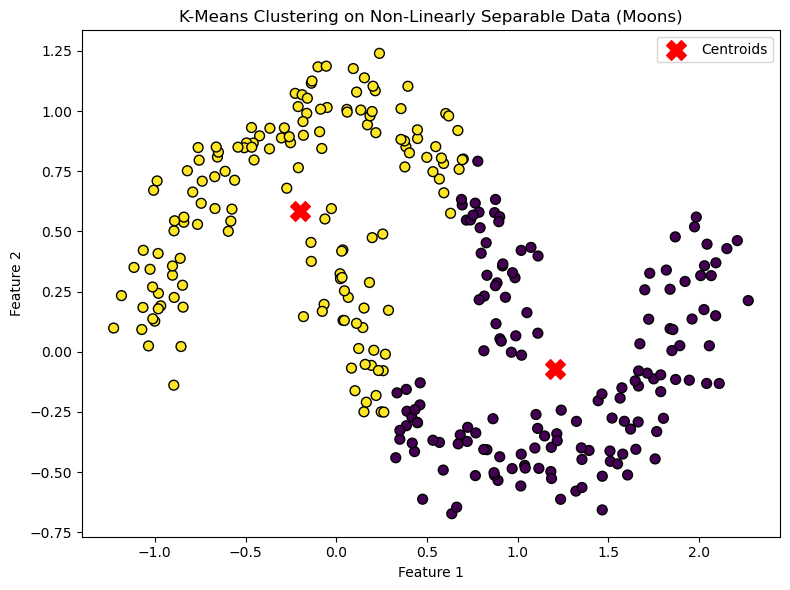

In [33]:
'''
39. Generate synthetic non-linearly separable data using make_moons, apply K-Means, and visualize the
clustering result.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans

# Generate non-linearly separable data
X, y_true = make_moons(n_samples=300, noise=0.1, random_state=42)

# Apply K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Plot the clustering result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
plt.scatter(kmeans.cluster_centers_[:, 0], 
            kmeans.cluster_centers_[:, 1], 
            c='red', marker='X', s=200, label='Centroids')

plt.title("K-Means Clustering on Non-Linearly Separable Data (Moons)")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()


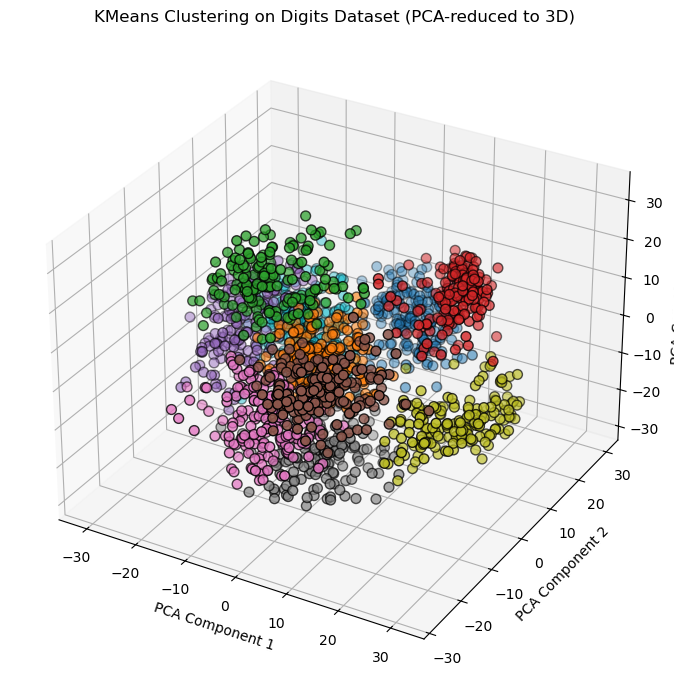

In [34]:
'''
40. Load the Digits dataset, apply PCA to reduce to 3 components, then use KMeans and visualize with a 3D
scatter plot.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from mpl_toolkits.mplot3d import Axes3D  # Enables 3D plotting

# Step 1: Load Digits dataset
digits = load_digits()
X = digits.data

# Step 2: Reduce to 3 components using PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X)

# Step 3: Apply KMeans clustering
kmeans = KMeans(n_clusters=10, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_pca)

# Step 4: 3D scatter plot
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2],
                     c=labels, cmap='tab10', s=50, edgecolor='k')

ax.set_title("KMeans Clustering on Digits Dataset (PCA-reduced to 3D)")
ax.set_xlabel("PCA Component 1")
ax.set_ylabel("PCA Component 2")
ax.set_zlabel("PCA Component 3")

plt.tight_layout()
plt.show()


Silhouette Score for KMeans clustering with 5 clusters: 0.7657


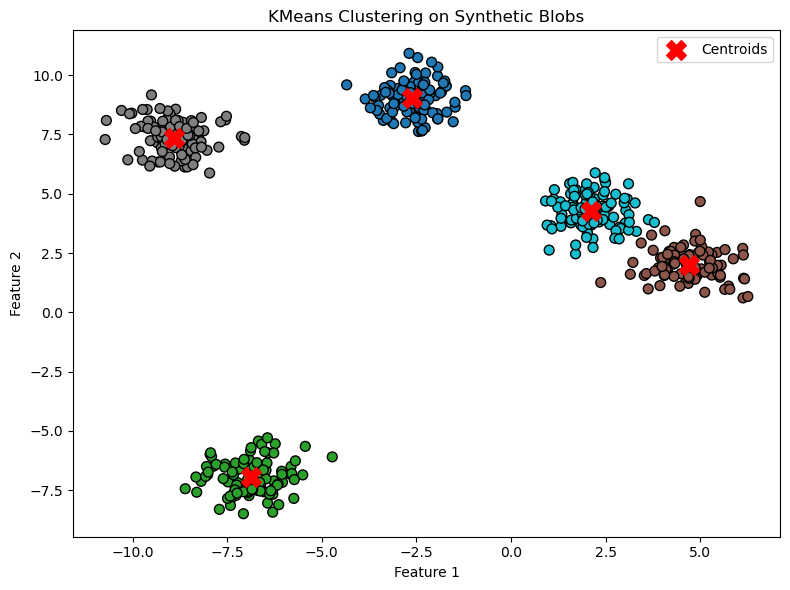

In [35]:
'''
41. Generate synthetic blobs with 5 centers and apply KMeans. Then use silhouette_score to evaluate the
clustering.
'''
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Step 1: Generate synthetic data with 5 centers
X, y_true = make_blobs(n_samples=500, centers=5, cluster_std=0.7, random_state=42)

# Step 2: Apply KMeans
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)

# Step 3: Calculate silhouette score
score = silhouette_score(X, labels)

print(f"Silhouette Score for KMeans clustering with 5 clusters: {score:.4f}")

# Step 4: Visualize the result
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', edgecolor='k', s=50)
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            c='red', s=200, marker='X', label='Centroids')
plt.title("KMeans Clustering on Synthetic Blobs")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.legend()
plt.tight_layout()
plt.show()


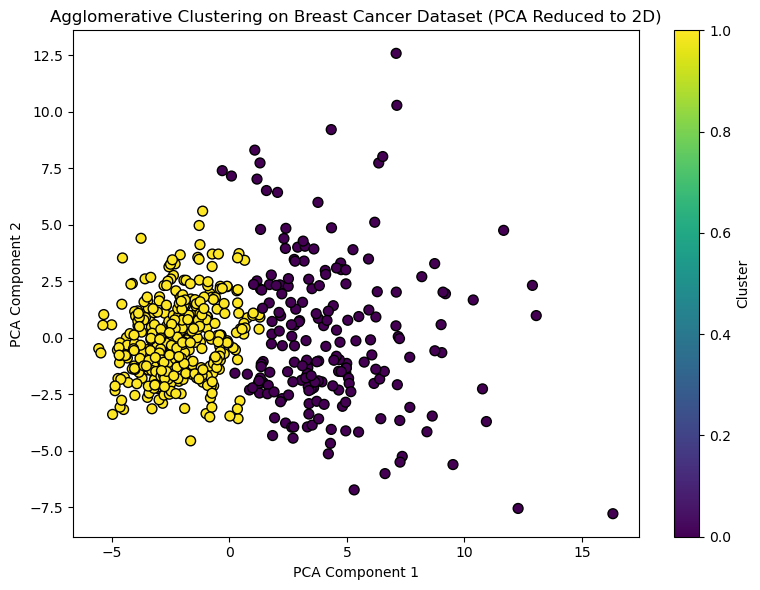

In [36]:
'''
42. Load the Breast Cancer dataset, reduce dimensionality using PCA, and apply Agglomerative Clustering.
Visualize in 2D.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.decomposition import PCA
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# Step 1: Load the Breast Cancer dataset
data = load_breast_cancer()
X = data.data
y_true = data.target

# Step 2: Scale the data (important for many clustering algorithms)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Step 3: Reduce dimensionality to 2 components using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Step 4: Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=2)
labels = agglo.fit_predict(X_pca)

# Step 5: Visualize the clustering result in 2D
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', edgecolor='k', s=50)
plt.title("Agglomerative Clustering on Breast Cancer Dataset (PCA Reduced to 2D)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.colorbar(label="Cluster")
plt.tight_layout()
plt.show()


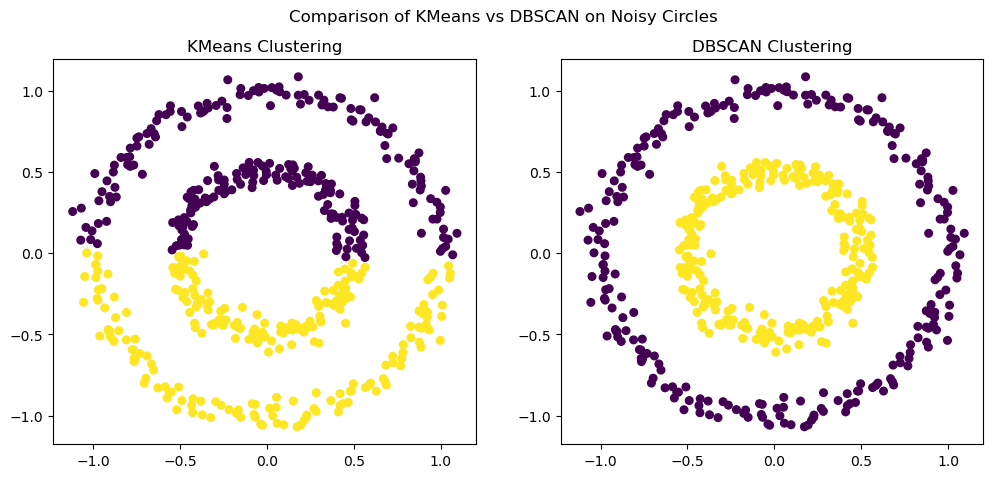

In [37]:
'''
43. Generate noisy circular data using make_circles and visualize clustering results from KMeans and DBSCAN
side-by-side.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.cluster import KMeans, DBSCAN

# Step 1: Generate circular data with noise
X, y = make_circles(n_samples=500, factor=0.5, noise=0.05, random_state=0)

# Step 2: Apply KMeans
kmeans = KMeans(n_clusters=2, random_state=0)
kmeans_labels = kmeans.fit_predict(X)

# Step 3: Apply DBSCAN
dbscan = DBSCAN(eps=0.2, min_samples=5)
dbscan_labels = dbscan.fit_predict(X)

# Step 4: Visualization
fig, axs = plt.subplots(1, 2, figsize=(12, 5))

# KMeans plot
axs[0].scatter(X[:, 0], X[:, 1], c=kmeans_labels, cmap='viridis', s=30)
axs[0].set_title('KMeans Clustering')

# DBSCAN plot
axs[1].scatter(X[:, 0], X[:, 1], c=dbscan_labels, cmap='viridis', s=30)
axs[1].set_title('DBSCAN Clustering')

plt.suptitle('Comparison of KMeans vs DBSCAN on Noisy Circles')
plt.show()


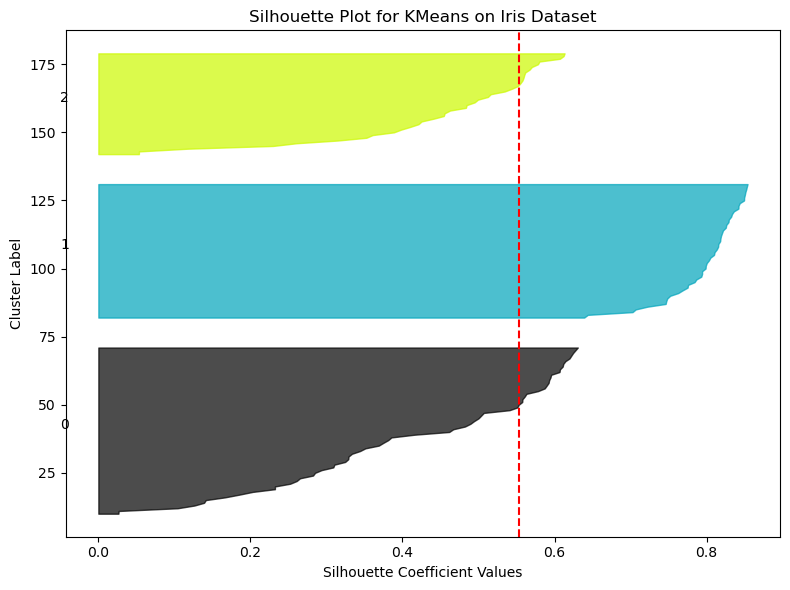

In [38]:
'''
44. Load the Iris dataset and plot the Silhouette Coefficient for each sample after KMeans clustering.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score
import numpy as np

# Step 1: Load Iris data
iris = load_iris()
X = iris.data

# Step 2: Apply KMeans
n_clusters = 3
kmeans = KMeans(n_clusters=n_clusters, random_state=0)
cluster_labels = kmeans.fit_predict(X)

# Step 3: Compute silhouette scores
silhouette_vals = silhouette_samples(X, cluster_labels)
avg_score = silhouette_score(X, cluster_labels)

# Step 4: Plot silhouette scores
y_lower = 10
fig, ax = plt.subplots(figsize=(8, 6))

for i in range(n_clusters):
    ith_cluster_silhouette_vals = silhouette_vals[cluster_labels == i]
    ith_cluster_silhouette_vals.sort()
    
    size_cluster_i = ith_cluster_silhouette_vals.shape[0]
    y_upper = y_lower + size_cluster_i
    
    color = plt.cm.nipy_spectral(float(i) / n_clusters)
    ax.fill_betweenx(np.arange(y_lower, y_upper),
                     0, ith_cluster_silhouette_vals,
                     facecolor=color, edgecolor=color, alpha=0.7)
    
    ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10  # 10 for spacing between clusters

ax.axvline(x=avg_score, color="red", linestyle="--")
ax.set_title("Silhouette Plot for KMeans on Iris Dataset")
ax.set_xlabel("Silhouette Coefficient Values")
ax.set_ylabel("Cluster Label")
plt.tight_layout()
plt.show()


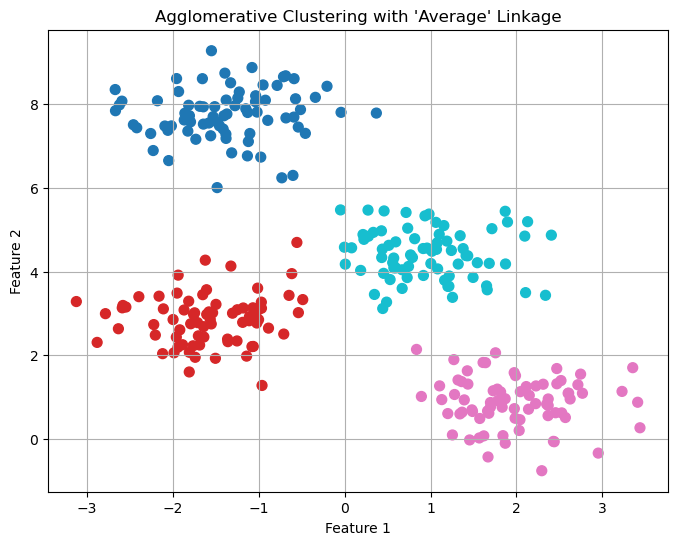

In [39]:
'''
45. Generate synthetic data using make_blobs and apply Agglomerative Clustering with 'average' linkage.
Visualize clusters.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import AgglomerativeClustering

# Step 1: Generate synthetic data
X, y_true = make_blobs(n_samples=300, centers=4, cluster_std=0.60, random_state=0)

# Step 2: Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=4, linkage='average')
labels = agglo.fit_predict(X)

# Step 3: Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10', s=50)
plt.title("Agglomerative Clustering with 'Average' Linkage")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


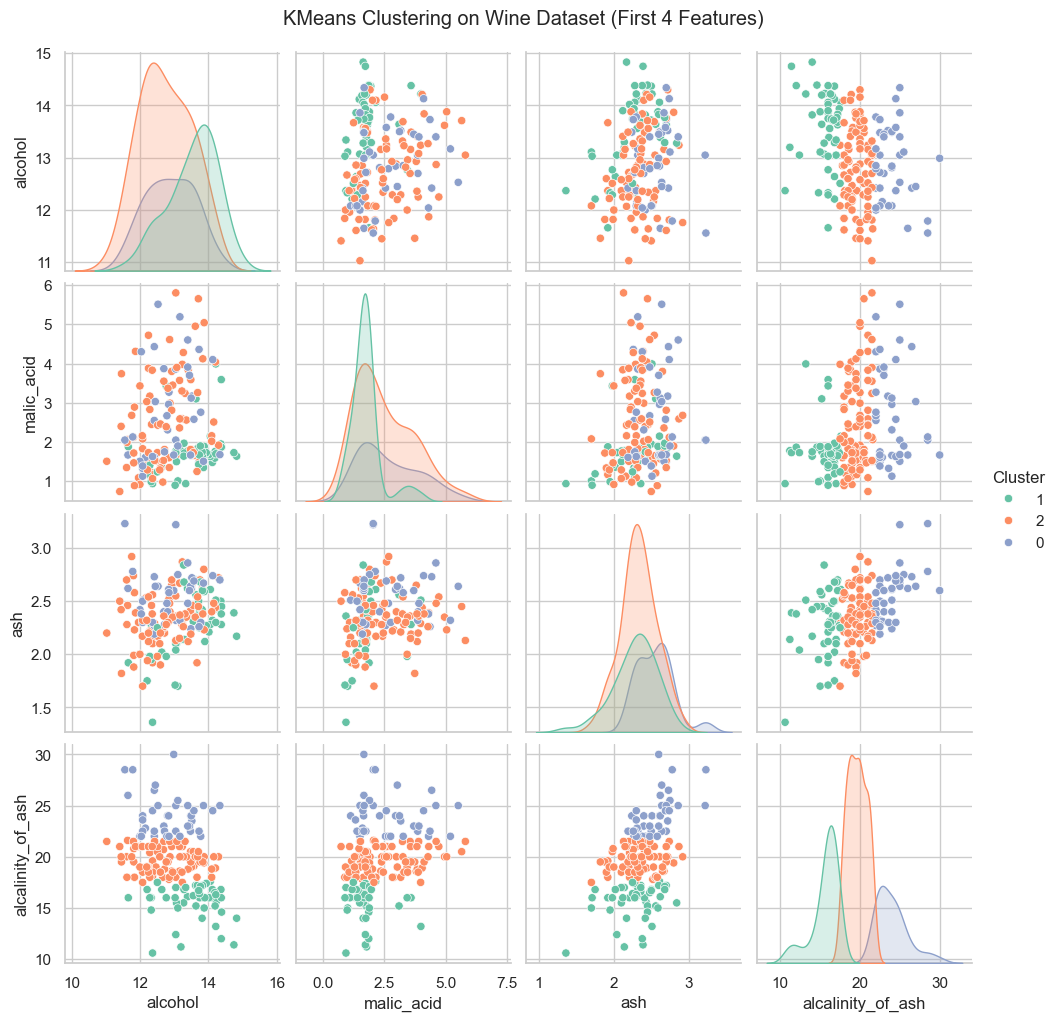

In [40]:
'''
46. Load the Wine dataset, apply KMeans, and visualize the cluster assignments in a seaborn pairplot (first 4
features).
'''
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.cluster import KMeans

# Step 1: Load the Wine dataset
wine = load_wine()
X = wine.data[:, :4]  # Use only the first 4 features
feature_names = wine.feature_names[:4]

# Step 2: Create DataFrame
df = pd.DataFrame(X, columns=feature_names)

# Step 3: Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
df['Cluster'] = kmeans.fit_predict(X).astype(str)  # Add cluster labels as strings for seaborn hue

# Step 4: Visualize using seaborn pairplot
sns.set(style="whitegrid")
pairplot = sns.pairplot(df, hue='Cluster', palette='Set2', diag_kind='kde')
pairplot.fig.suptitle("KMeans Clustering on Wine Dataset (First 4 Features)", y=1.02)
plt.show()


Estimated number of clusters: 3
Estimated number of noise points: 9
Noise: 9 points
Cluster 0: 165 points
Cluster 1: 161 points
Cluster 2: 165 points


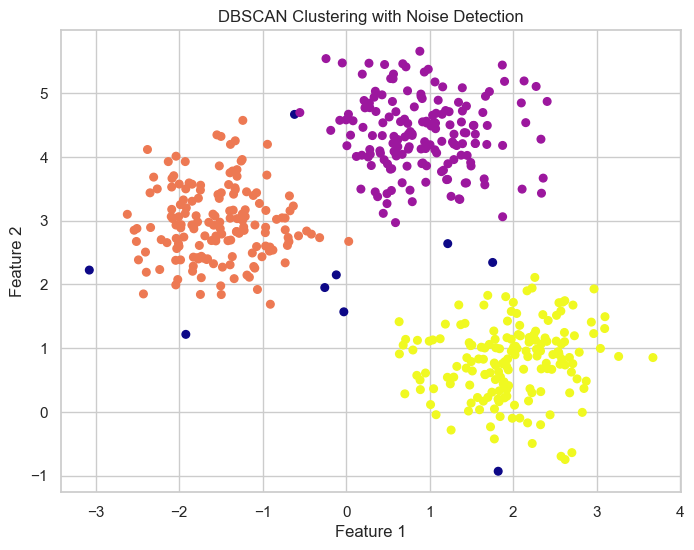

In [41]:
'''
47. Generate noisy blobs using make_blobs and use DBSCAN to identify both clusters and noise points. Print the
count.
'''
from sklearn.datasets import make_blobs
from sklearn.cluster import DBSCAN
import numpy as np
import matplotlib.pyplot as plt

# Step 1: Generate noisy blob data
X, _ = make_blobs(n_samples=500, centers=3, cluster_std=0.60, random_state=0)

# Step 2: Apply DBSCAN
db = DBSCAN(eps=0.5, min_samples=5)
labels = db.fit_predict(X)

# Step 3: Count clusters and noise
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
n_noise = list(labels).count(-1)

print(f"Estimated number of clusters: {n_clusters}")
print(f"Estimated number of noise points: {n_noise}")

# Optional: Count points per cluster
unique, counts = np.unique(labels, return_counts=True)
for label, count in zip(unique, counts):
    cluster_type = "Noise" if label == -1 else f"Cluster {label}"
    print(f"{cluster_type}: {count} points")

# Step 4: Visualization
plt.figure(figsize=(8, 6))
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='plasma', s=30)
plt.title("DBSCAN Clustering with Noise Detection")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()


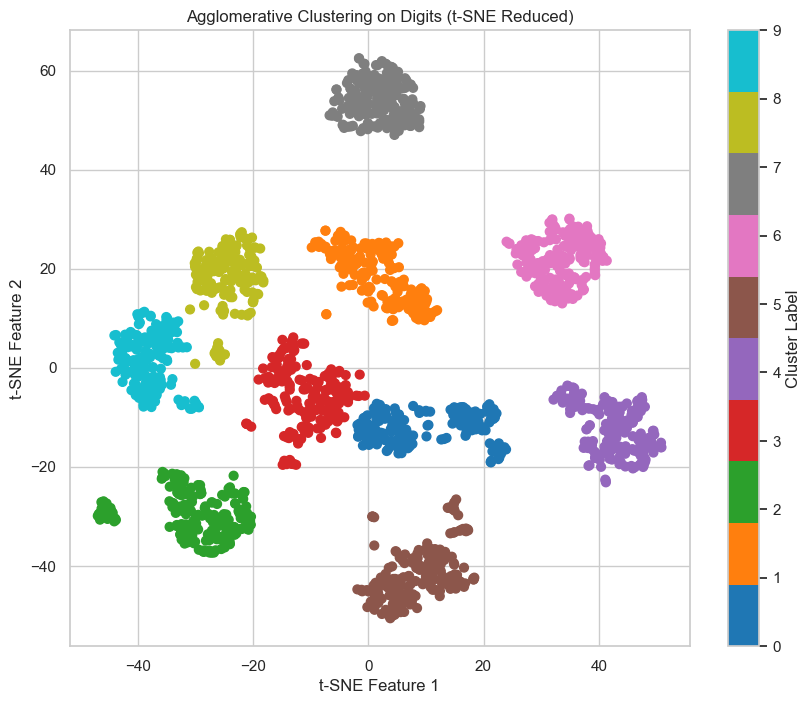

In [42]:
'''
48. Load the Digits dataset, reduce dimensions using t-SNE, then apply Agglomerative Clustering and plot the
clusters.
'''
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.manifold import TSNE
from sklearn.cluster import AgglomerativeClustering

# Step 1: Load the Digits dataset
digits = load_digits()
X = digits.data
y = digits.target  # Optional, if you want to compare with true labels

# Step 2: Reduce dimensions using t-SNE
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
X_2d = tsne.fit_transform(X)

# Step 3: Apply Agglomerative Clustering
agglo = AgglomerativeClustering(n_clusters=10, linkage='ward')
labels = agglo.fit_predict(X_2d)

# Step 4: Plot the clusters
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_2d[:, 0], X_2d[:, 1], c=labels, cmap='tab10', s=40)
plt.title("Agglomerative Clustering on Digits (t-SNE Reduced)")
plt.xlabel("t-SNE Feature 1")
plt.ylabel("t-SNE Feature 2")
plt.grid(True)
plt.colorbar(scatter, label='Cluster Label')
plt.show()
